## Diabetes Health Indicators: EDA & Preprocessing for NN
* What features help explain or predict diabetes?
* How does each feature differ between diabetic vs non-diabetic people? (target is binary)

Kaggle Dataset: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data?select=diabetes_binary_5050split_health_indicators_BRFSS2015.csv

Binary (0/1): 
* HighBP
* HighChol
* CholCheck
* Smoker
* Stroke
* HeartDiseaseorAttack
* PhysActivity
* Fruits
* Veggies
* HvyAlcoholConsump
* AnyHealthcare
* NoDocbcCost
* DiffWalk
* Sex

Numeric / continuous
* BMI
* MentHlth (1-30)
* PhysHlth (1-30)

Ordinal (numbers but represent categories)
* Age (1-13)
* Education (1-6)
* Income (1-8)
* GenHlth (1-5)


Plot types:
* Case A: numeric feature vs binary target --> Do diabetics have higher BMI than non-diabetics (boxplots)
* Case B: binary feature vs binary target --> Does high blood pressure increse likelihood of diabetes (countplot)
* Case C: correlations (overall relationships) --> Which variables are most strongly related to diabetes (scatterplot)

In [19]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
columns = [
    'HighBP', 
    'HighChol', 
    'CholCheck', 
    'BMI', 
    'Smoker', 
    'Stroke', 
    'HeartDiseaseorAttack', 
    'PhysActivity', 

    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'AnyHealthcare',
    'NoDocbcCost',
    'GenHlth',
    'MentHlth',
    'PhysHlth',
    'DiffWalk',
    'Sex',
    'Age',
    'Education',
    'Income'
]


df = pd.read_csv('diabetes.csv', header=0)
# figure out names VS header params in read_csv 
df = df.apply(pd.to_numeric)

print("--> head: quick look at the data <--")
print(df.head())
print("\n--> describe: summary stats <--")
print(df.describe())
print("\n--> info: data types and missing value <--")
print(df.info())
print("\n--> isnull: count missing values per column <--")
print(df.isnull().sum())
print("\n")

target = 'Diabetes_binary'
df['Diabetes_binary'].value_counts()

#corr = df.corr(numeric_only=True)
#print(corr['Diabetes_binary'].sort_values(ascending=False))


corr = df.corr()
print(corr['Diabetes_binary'].sort_values(ascending=True))

--> head: quick look at the data <--
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1              0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2              0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3              0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4              0.0     0.0       0.0        1.0  29.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           1.0     0.0  ...            1.0   
1                   0.0           0.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      3.0       

In [36]:
# Strong numeric predictors (from correlation)
numeric_features = [
    'BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth'
]

# Binary/categorical features
binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
    'DiffWalk', 'Sex'
]

# Ordinal features
ordinal_features = ['Education', 'Income']

Everything below 0.15 is a very weak correlation. 
Real world health data doesnt normally have super strong correlations (0.7-1).
This is a classification problem & correlation works best for linear relationships but diabetes is very complex and nonlinear.
Diabetes is a combination of things.
For this dataset, these values below have the strongest relationship to our target variable. 

* Age                     0.278738
* HighChol                0.289213
* BMI                     0.293373
* HighBP                  0.381516
* GenHlth                 0.407612

So instead of just thinking about correlations, I think about which variables differ between diabetics and non-diabetics.

<Axes: >

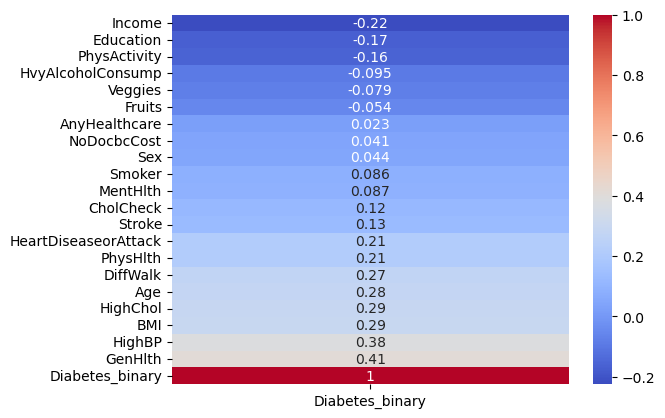

In [35]:
# too many attributes for normal heatmap. condense it.
corr = df.corr()
sns.heatmap(corr[['Diabetes_binary']].sort_values(by='Diabetes_binary', ascending=True),
            annot=True, cmap='coolwarm')

## A: Numeric Features V Target

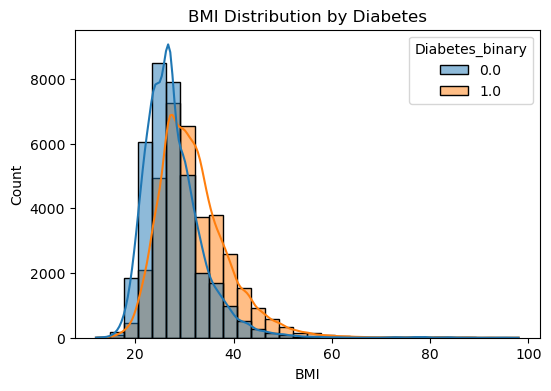

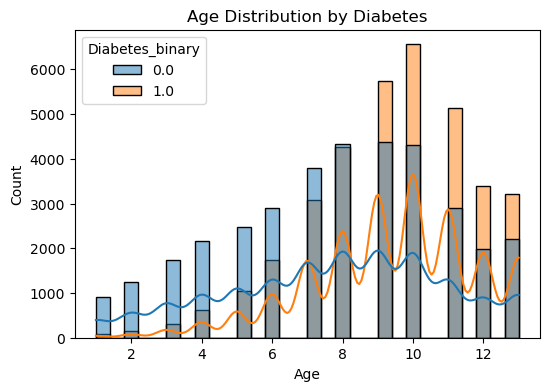

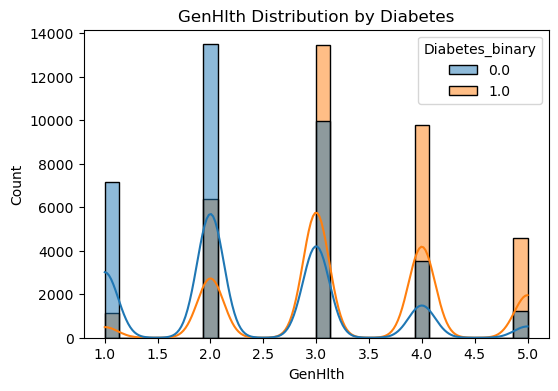

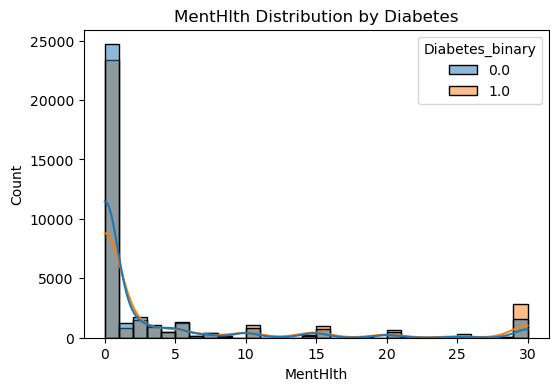

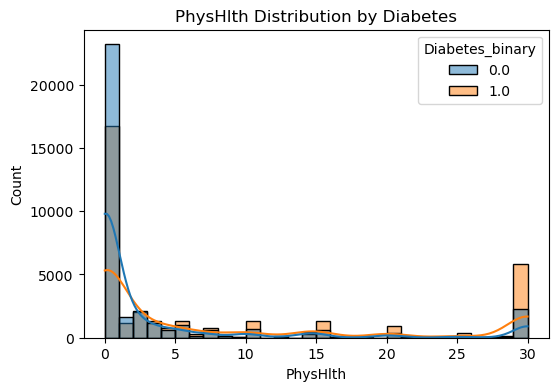

In [37]:
for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df,
        x=feature,
        hue=target,
        bins=30,
        kde=True
    )
    plt.title(f'{feature} Distribution by Diabetes')
    plt.show()

## B: Binary Features vs Target

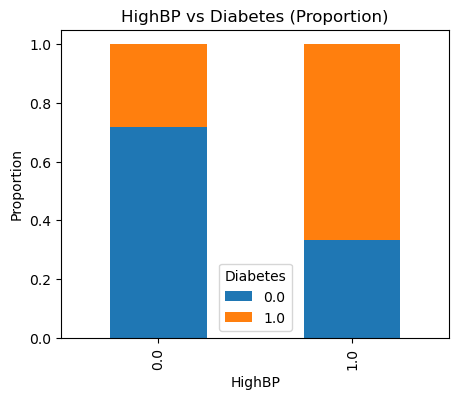

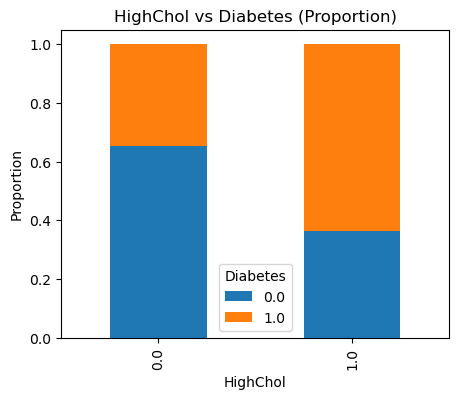

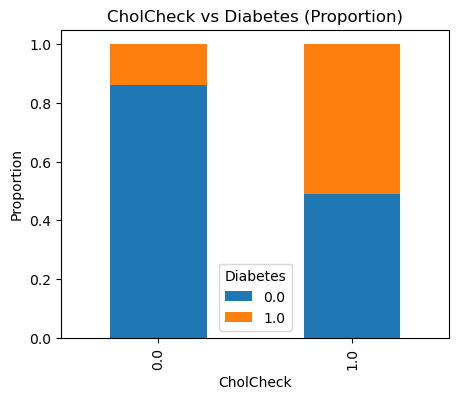

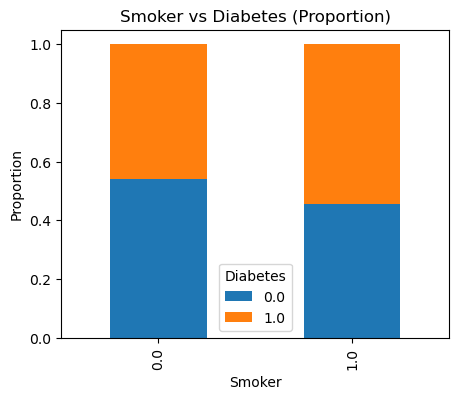

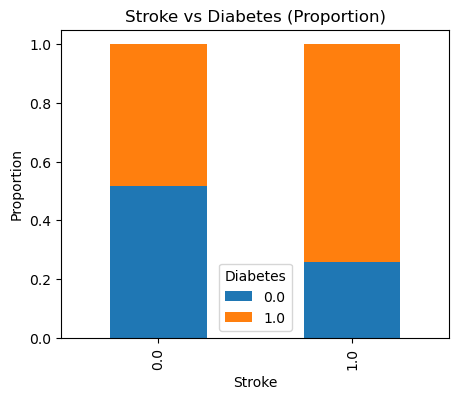

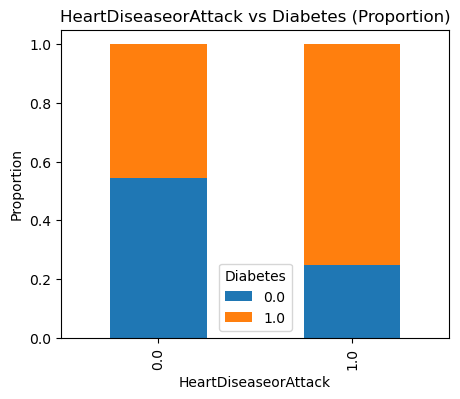

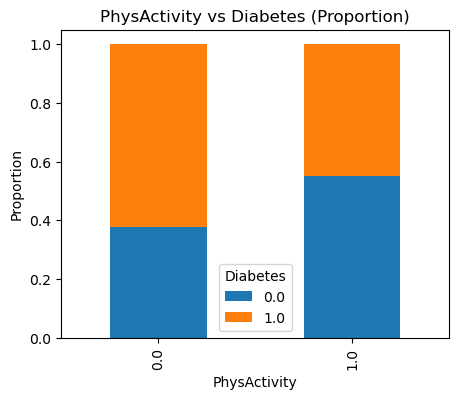

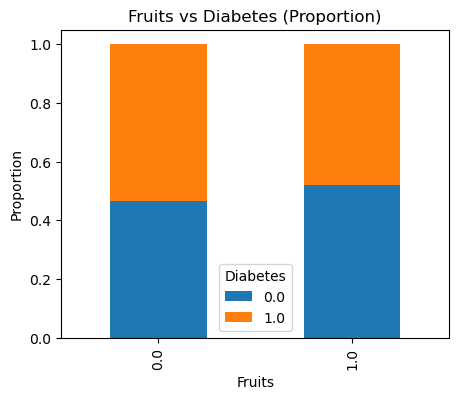

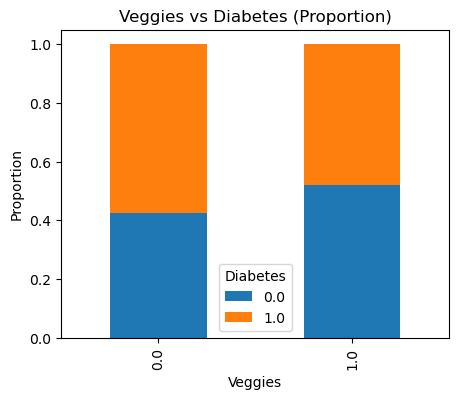

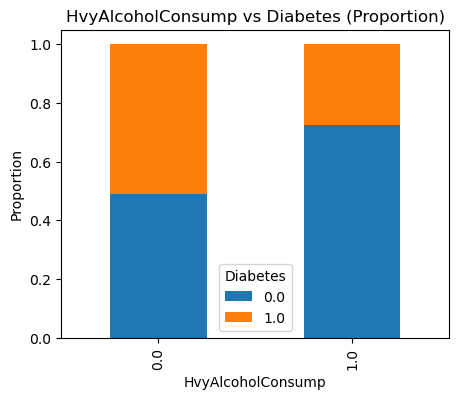

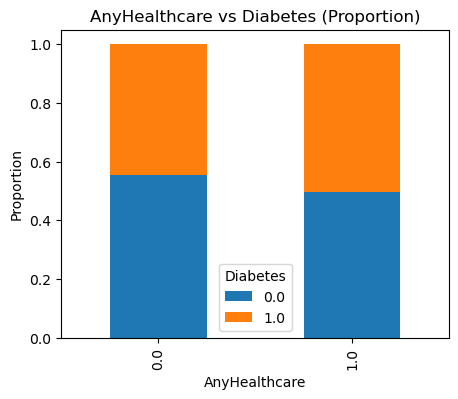

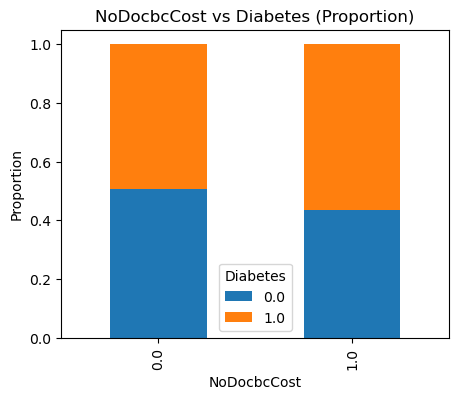

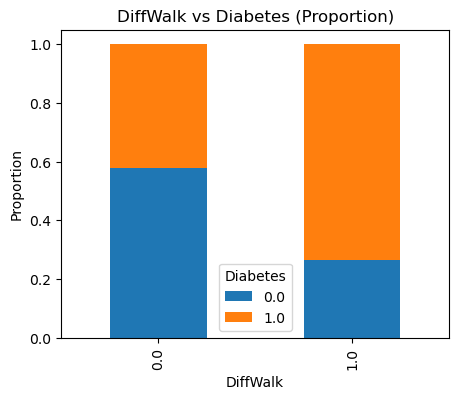

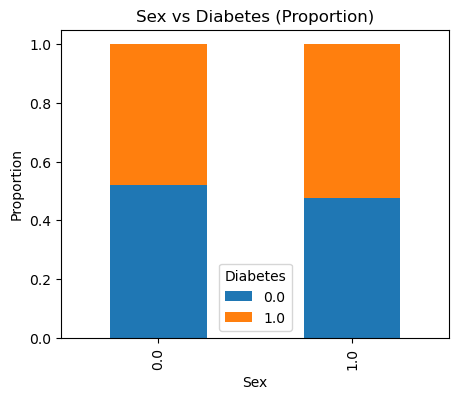

In [38]:
for feature in binary_features:
    ct = pd.crosstab(df[feature], df[target], normalize='index')

    ct.plot(kind='bar', stacked=True, figsize=(5, 4))
    plt.title(f'{feature} vs Diabetes (Proportion)')
    plt.ylabel('Proportion')
    plt.xlabel(feature)
    plt.legend(title='Diabetes')
    plt.show()

## C: Ordinal Features

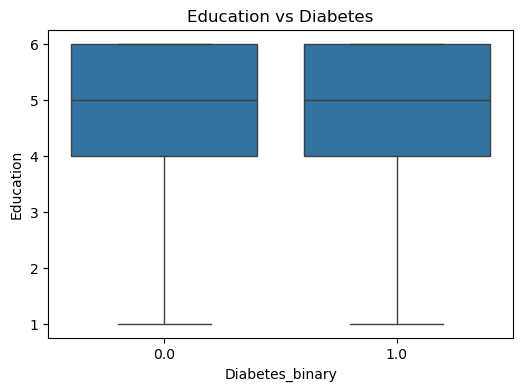

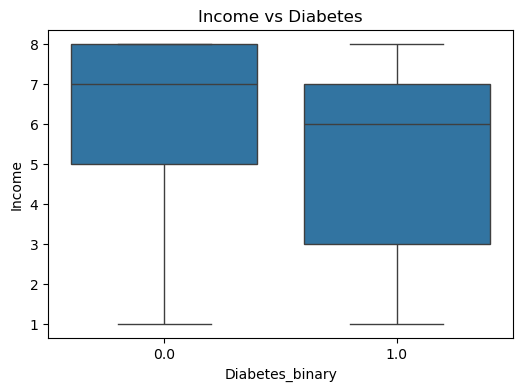

In [39]:
for feature in ordinal_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=target, y=feature, showfliers=False)
    plt.title(f'{feature} vs Diabetes')
    plt.show()

## Top Features

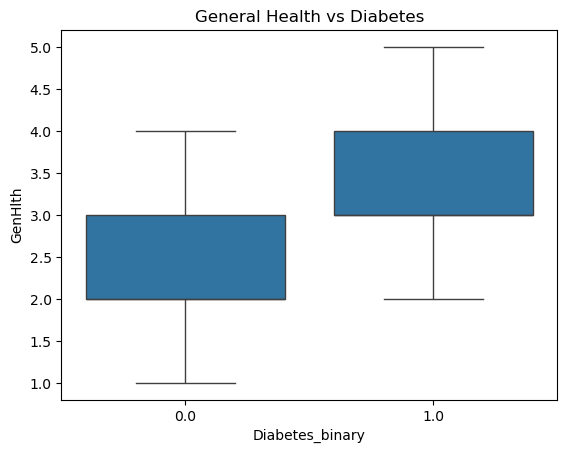

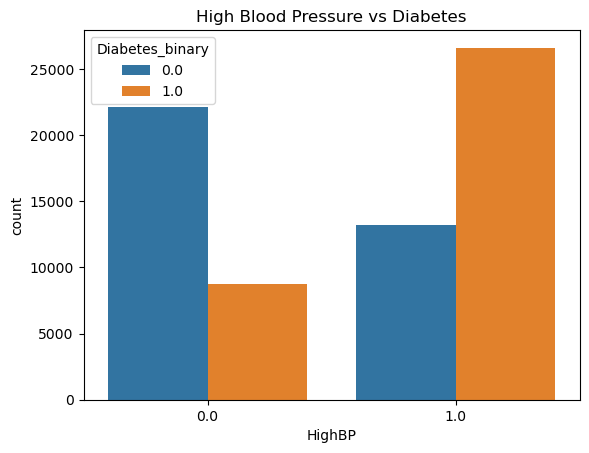

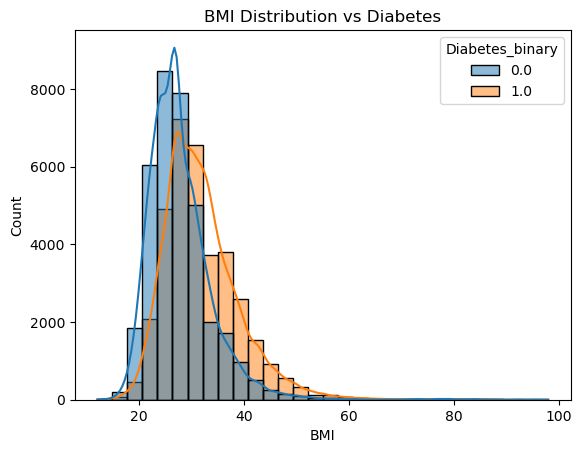

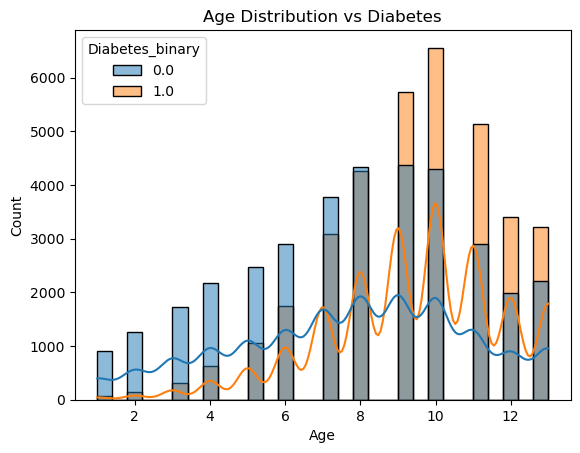

In [40]:
top_features = ['GenHlth', 'HighBP', 'BMI', 'Age']

# GenHlth (ordinal)
sns.boxplot(data=df, x=target, y='GenHlth', showfliers=False)
plt.title('General Health vs Diabetes')
plt.show()

# HighBP (binary)
sns.countplot(data=df, x='HighBP', hue=target)
plt.title('High Blood Pressure vs Diabetes')
plt.show()

# BMI (distribution)
sns.histplot(data=df, x='BMI', hue=target, bins=30, kde=True)
plt.title('BMI Distribution vs Diabetes')
plt.show()

# Age (distribution)
sns.histplot(data=df, x='Age', hue=target, bins=30, kde=True)
plt.title('Age Distribution vs Diabetes')
plt.show()

In [42]:
#sns.pairplot(df[['BMI', 'Age', 'GenHlth', 'HighBP', target]], hue=target)
#plt.show()